# Szacowanie skuteczności szczepionki na podstawie badania randomizowanego metodą czasu do pierwszego zakażenia

## Podsumowanie dla kierownictwa

## Szacowanie skuteczności szczepionki na podstawie badania randomizowanego

Kluczowe badanie szczepionki fazy III randomizuje uczestników w stosunku 1:1 do grupy **szczepionki** lub **placebo** i obserwuje każdą osobę aż do jej pierwszego zakażenia potwierdzonego laboratoryjnie albo do cenzurowania administracyjnego na końcu okna rekrutacji i obserwacji. Regulacyjnym pierwszorzędowym punktem końcowym jest **skuteczność szczepionki (VE)**, zdefiniowana jako `VE = 1 - hazard ratio (vaccine vs. placebo)`. Ponieważ uczestnicy wchodzą do badania według rozłożonego w czasie harmonogramu, a większość nigdy nie ulega zakażeniu, dane są cenzurowane prawostronnie i to metody analizy przeżycia — a nie proste proporcje — dają obronną estymację.

Ten notatnik przeprowadza analizę punktu końcowego od początku do końca na syntetycznym, zrównoważonym badaniu obejmującym **100 uczestników (50 szczepionka, 50 placebo)**:

- **PROC FREQ** buduje tabelę dwa na dwa współczynników zachorowań (ramię według statusu zakażenia) wraz z testem chi-kwadrat, ryzykiem względnym i różnicą ryzyka — opisowy obraz „surowego VE", który recenzent kliniczny widzi jako pierwszy.
- **PROC MEANS** podsumowuje czas obserwacji osób (łączne i średnie dni obserwacji) oraz surowe liczby zakażeń w każdym ramieniu, ujawniając niezrównoważenie cenzurowania, które uzasadnia zastosowanie modelu czasu do zdarzenia.
- **PROC LIFETEST** estymuje krzywe przeżycia Kaplana-Meiera dla każdego ramienia i przeprowadza testy jednorodności **log-rank i Wilcoxona** — nieparametryczne potwierdzenie, że krzywe się rozdzielają.
- **PROC PHREG** dopasowuje model proporcjonalnych hazardów Coxa z uwzględnieniem wieku, płci i wyjściowego ryzyka narażenia, raportuje hazard ratio z jego 95% granicami ufności, a instrukcja **HAZARDRATIO** bezpośrednio ujmuje kontrast między ramionami. Skorygowane VE odczytuje się jako `1 - HR`.

**Jak odczytać wynik.** W zweryfikowanym przebiegu surowa proporcja zakażeń wynosi **64% w grupie placebo wobec 30% w grupie szczepionki** (chi-kwadrat p = 0.0007), test log-rank odrzuca równość krzywych przeżycia (χ² = 11.25, p = 0.0008), a skorygowane hazard ratio Coxa dla szczepionki wobec placebo wynosi **0.369** z 95% przedziałem ufności **(0.198, 0.687)** — całkowicie poniżej 1 — czyli szacowane VE wynosi około **63%** (`1 - 0.369`). Górna granica ufności HR równa 0.687 odpowiada dolnej granicy skuteczności bliskiej 31%, na skraju konwencjonalnego progu rejestracyjnego 30-50% dla tak małego badania. Wyjściowe zajęcie o wysokim narażeniu w przybliżeniu potraja hazard zakażenia (HR = 3.47, p < .0001), potwierdzając, że korekta o zmienne towarzyszące ma znaczenie; wiek i płeć niosą efekty graniczne (p ≈ 0.06), które nie osiągają istotności na poziomie 0.05. Spójność surowej tabeli dwa na dwa, rozdzielonych krzywych KM oraz skorygowanej estymacji Coxa to dokładnie ta triangulacja, jakiej Rada ds. Monitorowania Bezpieczeństwa Danych oczekuje przed ogłoszeniem skuteczności.

*Wyłącznie dane syntetyczne — generowane bezpośrednio w kodzie za pomocą `streaminit`/`rand`; brak plików zewnętrznych i sieci. Wykonuje się znacznie poniżej minuty.*

## Źródła danych

**Syntetyczny zbiór danych `trial`** — jeden wiersz na zapisanego uczestnika, generowany bezpośrednio w pierwszej komórce kodu (ziarno `20260605`). 100 uczestników, zrównoważonych 1:1 (50 szczepionka, 50 placebo), wykładniczy czas do zakażenia z redukcją hazardu o ~70% w ramieniu szczepionki, rozłożone w czasie wejście oraz cenzurowanie administracyjne na końcu 540-dniowego okna.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `subjid` | Num | Identyfikator uczestnika (1-100) |
| `arm` | Char | Ramię leczenia: `Vaccine` lub `Placebo` |
| `arm_n` | Num | Numeryczna flaga ramienia (1 = szczepionka, 0 = placebo) |
| `age` | Num | Wiek w latach przy rekrutacji (18-85) |
| `sex` | Char | Płeć: `F` lub `M` |
| `baseline_risk` | Num | Wskaźnik zajęcia o wysokim narażeniu (1 = tak) |
| `fu_days` | Num | Czas obserwacji w dniach do pierwszego zakażenia lub cenzurowania |
| `infected` | Num | Wskaźnik zdarzenia: 1 = zaobserwowano zakażenie, 0 = cenzurowane |

# Szacowanie skuteczności szczepionki na podstawie badania randomizowanego

**Analiza przeżycia czasu do pierwszego zakażenia**

Pierwszorzędowym punktem końcowym skuteczności w badaniu szczepionki jest **hazard zakażenia** w ramieniu szczepionki względem placebo. Definiujemy

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Ponieważ uczestnicy wchodzą do badania według rozłożonego w czasie harmonogramu, a większość nigdy nie ulega zakażeniu przed końcem obserwacji, dane są cenzurowane prawostronnie: proste porównanie proporcji zakażonych marnuje informację o czasie i jest obciążone nierówną obserwacją. Dlatego budujemy estymację w trzech warstwach — surowa tabela dwa na dwa współczynników zachorowań, nieparametryczne krzywe Kaplana-Meiera z testem log-rank oraz skorygowany model proporcjonalnych hazardów Coxa — i sprawdzamy, czy wszystkie trzy opowiadają tę samą historię.

W analizie wykorzystano **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST** oraz **PROC PHREG**.

## 1. Wygenerowanie syntetycznego badania

Symulujemy zrównoważone, 100-osobowe badanie randomizowane 1:1 (50 szczepionka, 50 placebo — przypisane według parzystości numeru uczestnika, tak aby ramiona były dokładnie równe). Czas do pierwszego zakażenia jest losowany z rozkładu wykładniczego, którego dzienny hazard zależy od ramienia (szczepionka obniża hazard do 30% placebo), wieku oraz flagi zajęcia o wysokim narażeniu. Rozłożone w czasie wejście plus stałe 540-dniowe okno tworzą realistyczne cenzurowanie prawostronne: każdy, kto nie zakaził się do końca swojej obserwacji, jest cenzurowany.

In [1]:
/* Syntetyczne randomizowane badanie szczepionki: czas do pierwszego zakażenia */
DANE trial;
    CALL streaminit(20260605);
    DŁUGOŚĆ arm $12 sex $1;
    enroll_days = 540;            /* okno rekrutacji + obserwacji */
    POWTÓRZ subjid = 1 TO 100;
        /* randomizacja 1:1 szczepionka vs placebo: 50 na grupę,
           przydział wg naprzemiennej parzystości dla zrównoważonego badania */
        JEŚLI mod(subjid, 2) = 1 WTEDY POWTÓRZ;
            arm = 'Szczepionka'; arm_n = 1;
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            arm = 'Placebo'; arm_n = 0;
        KONIEC;

        /* zmienne wyjściowe */
        AGE = round(rand('NORMAL', 47, 14));
        JEŚLI AGE < 18 WTEDY AGE = 18;
        JEŚLI AGE > 85 WTEDY AGE = 85;
        JEŚLI rand('BERNOULLI', 0.52) = 1 WTEDY sex = 'K'; PRZECIWNIE sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* zawód o wysokiej ekspozycji */

        /* dzienny hazard zakażenia: placebo bazowo, szczepionka obniża ~70% */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        JEŚLI arm_n = 1 WTEDY ve_factor = 0.30; PRZECIWNIE ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* czas do pierwszego zakażenia z hazardu wykładniczego */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* cenzurowanie administracyjne przy schodkowym wejściu */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        JEŚLI t_inf <= t_cens WTEDY POWTÓRZ;
            fu_days = round(t_inf);
            infected = 1;
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            fu_days = round(t_cens);
            infected = 0;
        KONIEC;
        JEŚLI fu_days < 1 WTEDY fu_days = 1;
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ subjid arm arm_n AGE sex baseline_risk fu_days infected;
WYKONAJ;


NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 2. Tabela dwa na dwa współczynników zachorowań

Najprostszy obraz skuteczności: tabela krzyżowa ramienia względem statusu zakażenia. Test chi-kwadrat sprawdza, czy zakażenie jest niezależne od ramienia; `RELRISK` raportuje ryzyko względne i iloraz szans; `RISKDIFF` podaje bezwzględną różnicę ryzyka wraz z jej przedziałem ufności. Jest to obraz *surowy* (nieskorygowany, ignorujący obserwację) — użyteczny jako kontrola poprawności, lecz nie jest to estymacja regulacyjna.

                                             Częstość zakażeń według grupy                                              

                                                   The FREQ Procedure

Table of Grupa by Zakażenie

Grupa       |         0 |         1 |      Total
------------+-----------+-----------+-----------
Placebo     |        18 |        32 |         50
------------+-----------+-----------+-----------
Szczepionka |        35 |        15 |         50
------------+-----------+-----------+-----------
Total       |        53 |        47 |        100

Statistics for Table of Grupa by Zakażenie

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


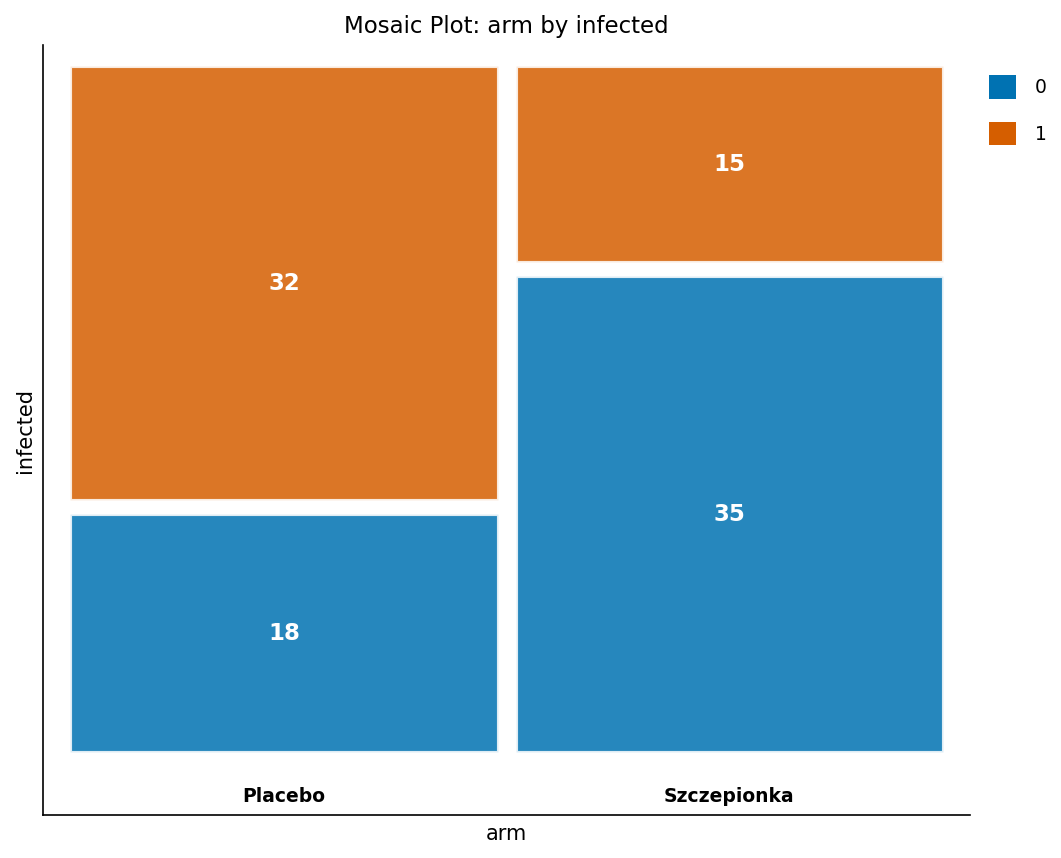

In [2]:
PROCEDURA CZĘSTOŚCI DANE=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    ETYKIETA arm="Grupa" infected="Zakażenie";
    TYTUŁ "Częstość zakażeń według grupy";
WYKONAJ;
TYTUŁ;

## 3. Czas obserwacji osób i liczby zdarzeń według ramienia

Zanim zaufamy surowej tabeli dwa na dwa, kwantyfikujemy niezrównoważenie obserwacji. `PROC MEANS` raportuje łączne i średnie dni obserwacji oraz liczbę zakażeń w każdym ramieniu. Jeśli ramię szczepionki gromadzi *więcej* czasu obserwacji osób (mniej wczesnych zdarzeń), surowa proporcja zaniża skuteczność — i właśnie dlatego następnie przechodzimy do modelu czasu do zdarzenia.

In [3]:
PROCEDURA ŚREDNIE DANE=trial n sum mean maxdec=2;
    KLASA arm;
    ZMIENNA fu_days infected;
    ETYKIETA arm="Grupa" fu_days="Dni obserwacji" infected="Zakażenie";
    TYTUŁ "Obserwacja i zakażenia według grupy";
WYKONAJ;
TYTUŁ;

                                          Obserwacja i zakażenia według grupy                                           

                                                  The MEANS Procedure

                                       Analysis Variable : fu_days Dni obserwacji

        Grupa                N Obs            Sum           Mean
        --------------------------------------------------------
        Placebo                 50       14552.00         291.04
        Szczepionka             50       19438.00         388.76
        --------------------------------------------------------

                                        Analysis Variable : infected Zakażenie

        Grupa                N Obs            Sum           Mean
        --------------------------------------------------------
        Placebo                 50          32.00           0.64
        Szczepionka             50          15.00           0.30
        --------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Krzywe Kaplana-Meiera i test log-rank

`PROC LIFETEST` estymuje funkcję przeżycia metodą iloczynowo-graniczną (Kaplana-Meiera) — tutaj prawdopodobieństwo pozostania wolnym od zakażenia w czasie — oddzielnie dla każdego ramienia. `STRATA arm / test=(logrank wilcoxon)` żąda dwóch standardowych testów jednorodności: test **log-rank** waży wszystkie czasy zdarzeń jednakowo (najsilniejszy przy proporcjonalnych hazardach), natomiast **Wilcoxon** silniej waży wczesne zdarzenia. Zgodność między nimi wspiera założenie proporcjonalnych hazardów, na którym opierać się będzie model Coxa. `ATRISK` dopisuje liczbę osób nadal narażonych.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

   Stratum: Grupa = Placebo   

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47                 1
 39.0000    0.9000     0.0424              46                 1
 40.0000    0.8800     0.0460              45    


NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


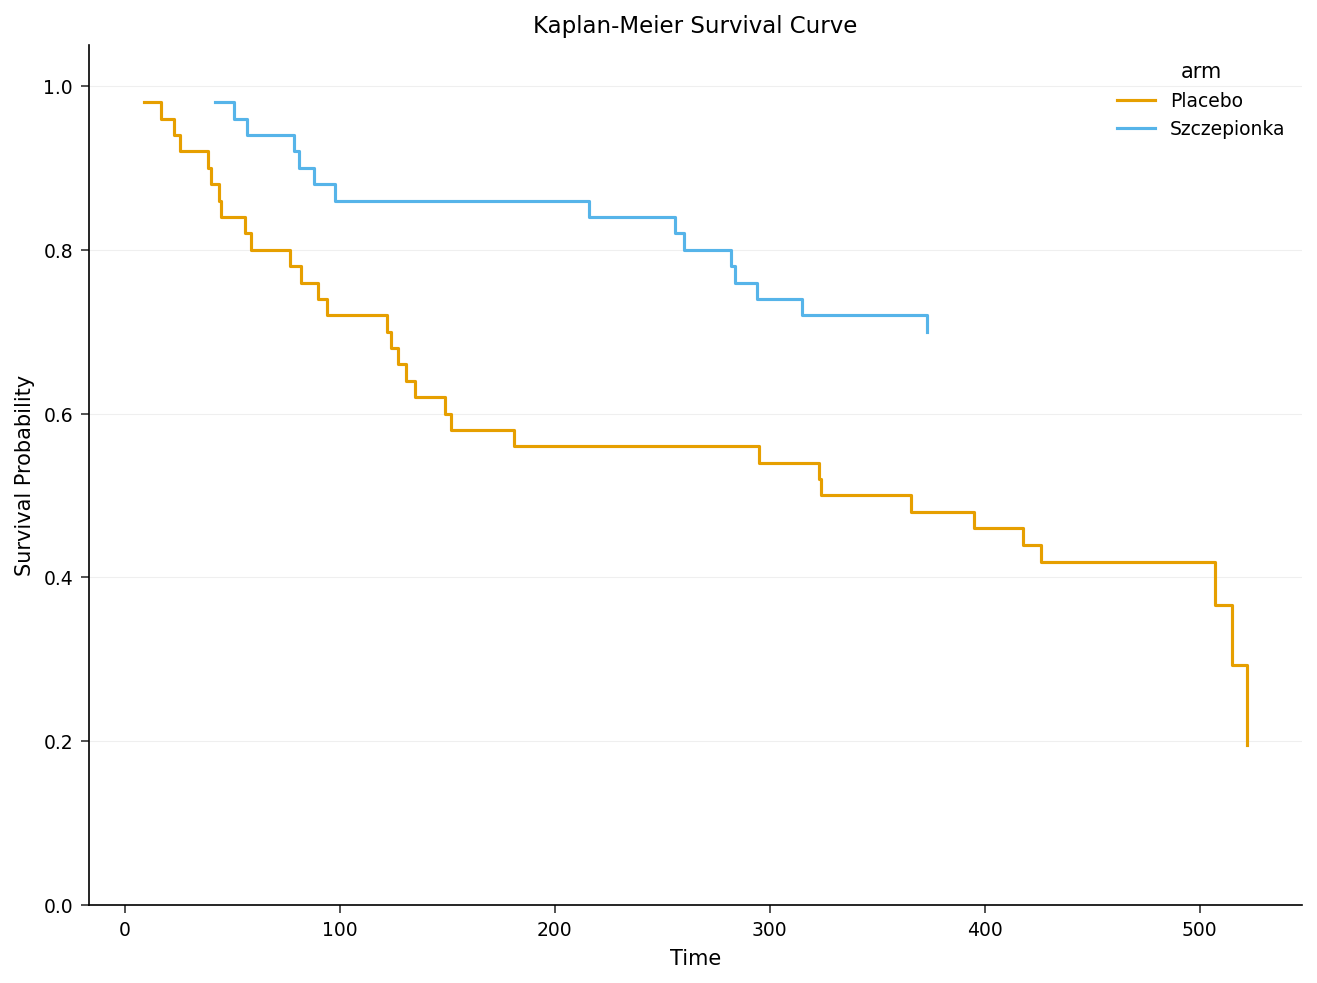

In [4]:
PROCEDURA LIFETEST DANE=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    ETYKIETA fu_days="Dni obserwacji" arm="Grupa";
    TYTUŁ "Krzywe przeżycia Kaplana-Meiera według grupy";
WYKONAJ;
TYTUŁ;

## 5. Skorygowany model Coxa i skuteczność szczepionki

Model proporcjonalnych hazardów Coxa daje **skorygowane** hazard ratio, kontrolując wiek, płeć i wyjściowe ryzyko narażenia. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` ustawia kodowanie referencyjne, tak że współczynnik `ARM` jest logarytmem hazard ratio szczepionki wobec placebo. `TIES=EFRON` to zalecana metoda obsługi wiązań; `RL` drukuje granice ufności hazard ratio. Instrukcje `HAZARDRATIO` raportują kontrast między ramionami (granice Walda) oraz efekt wieku na każdy przyrost o 10 lat.

**Skuteczność szczepionki odczytuje się bezpośrednio jako `VE = 1 - HR` dla członu ramienia**, a górna granica ufności HR odpowiada dolnej granicy skuteczności, od której zależą decyzje rejestracyjne.

In [5]:
PROCEDURA PHREG DANE=trial;
    KLASA arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    MODEL fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    hazardratio 'Szczepionka vs Placebo' arm / cl=wald;
    hazardratio AGE / units=10;
    ETYKIETA fu_days="Dni obserwacji" arm="Grupa" AGE="Wiek" sex="Płeć"
          baseline_risk="Wysokie ryzyko ekspozycji";
    TYTUŁ "Model proporcjonalnych hazardów Coxa";
WYKONAJ;
TYTUŁ;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                           Analysis of Maximum Likelihood Estimates                                            

Parameter                        DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
ARM_SZCZEPIONKA  


NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Interpretacja

Trzy warstwy triangulują do jednego wniosku o skuteczności:

- **Surowy współczynnik zachorowań (PROC FREQ).** Proporcja zakażeń wynosi **64% w grupie placebo (32/50) wobec 30% w grupie szczepionki (15/50)** — różnica ryzyka **-0.34** (95% CI -0.524 do -0.156) i iloraz szans **0.241** (95% CI 0.105 do 0.556). Test chi-kwadrat odrzuca niezależność (χ² = 11.60, p = 0.0007). Jest to sygnał widoczny na pierwszy rzut oka, którego recenzent oczekuje najpierw — pomija jednak rozłożoną w czasie, nierówną obserwację.

- **Czas obserwacji osób (PROC MEANS).** Średnia obserwacja jest dłuższa w ramieniu szczepionki (**388.8 wobec 291.0 dni**) właśnie dlatego, że mniej uczestników wychodzi wcześnie wskutek zakażenia (15 zdarzeń w grupie szczepionki wobec 32 w placebo). Potwierdza to, że surowa proporcja jest konserwatywnym, zaburzonym przez obserwację obrazem, i uzasadnia analizę czasu do zdarzenia.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** Krzywe przeżycia rozdzielają się wyraźnie — placebo osiąga **medianę czasu wolnego od zakażenia równą 324 dni, podczas gdy mediana dla szczepionki nie zostaje osiągnięta** (tylko 15 z 50 zaszczepionych kiedykolwiek uległo zakażeniu). Oba testy jednorodności odrzucają równość: **log-rank χ² = 11.25 (p = 0.0008)** oraz **Wilcoxon χ² = 9.11 (p = 0.0025)**. Ich zgodność wspiera założenie proporcjonalnych hazardów leżące u podstaw modelu Coxa.

- **Skorygowany model Coxa (PROC PHREG).** Po skorygowaniu o wiek, płeć i wyjściowe ryzyko narażenia hazard ratio szczepionki wobec placebo wynosi **0.369** z 95% CI **(0.198, 0.687)** całkowicie poniżej 1 (p = 0.0017), co daje szacowaną **skuteczność szczepionki na poziomie około 63%** (`VE = 1 - 0.369`). Dolna granica skuteczności (z górnej granicy ufności HR równej 0.687) jest bliska **31%**, na skraju konwencjonalnego progu rejestracyjnego 30-50% — szeroka, zgodnie z oczekiwaniami dla badania na 100 osobach. Zajęcie o wysokim narażeniu w przybliżeniu potraja hazard zakażenia (**HR = 3.47**, 95% CI 1.90-6.35, p < .0001), co potwierdza zasadność korekty o zmienne towarzyszące; wiek (HR = 1.022 na rok, p = 0.059) i płeć żeńska (HR = 0.541, p = 0.064) niosą efekty graniczne, które nie osiągają istotności na poziomie 0.05. Globalna hipoteza zerowa zostaje odrzucona (χ² ilorazu wiarygodności = 29.0, p < .0001).

**Wniosek końcowy.** Ponieważ surowa tabela dwa na dwa, rozdzielone krzywe Kaplana-Meiera oraz skorygowana estymacja Coxa wskazują ten sam kierunek, a przedziały ufności wykluczają brak efektu, badanie wspiera sygnał skuteczności — choć szerokie granice ufności odzwierciedlają małą próbę. W rzeczywistym zgłoszeniu rejestracyjnym to estymacja Coxa `1 - HR` i jej przedział ufności — a nie surowa proporcja — byłyby pierwszorzędowym punktem końcowym, natomiast wyniki FREQ i LIFETEST służyłyby jako wspomagające potwierdzenie opisowe i nieparametryczne, które Rada ds. Monitorowania Bezpieczeństwa Danych rozpatruje wraz z nimi.